In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [24]:
df_test = pd.read_csv('data/test_02_Test_2026-08-07_16h16.51.553.csv')
df_test.head()

/var/folders/dm/sbdv31d55_3000ql2l05ttm5pl5dqc/T/ipykernel_11414/662920066.py:1: DtypeWarning: Columns (0: start_again_key.keys, 1: key_resp_start.keys, 2: pause_loop.start_again_key.keys) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('data/test_02_Test_2026-08-07_16h16.51.553.csv')


,trial_number,familiar_stimulus,novel_stimulus,familiar_stimulus_item,novel_stimulus_item,complexity_condition,familiarization_time,familiar_stimulus_path,novel_stimulus_path,familiar_location_1,...,Stop_ET.stopped,participant,order_number,date,expName,expVersion,psychopyVersion,frameRate,expStart,Unnamed: 128
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,test_02,12,2026-08-07_16h17.04.402,Test,NaN,2025.2.4,60.02855,2026-08-07 16h17.04.991316 +1200,NaN
1,1.0,Frac4B_Complex,Frac4A_Complex,4B,4A,complex,10.0,stimuli/images/Frac4B_Complex.png,stimuli/images/Frac4A_Complex.png,right,...,NaN,test_02,12,2026-08-07_16h17.04.402,Test,NaN,2025.2.4,60.02855,2026-08-07 16h17.04.991316 +1200,NaN
2,1.0,Frac4B_Complex,Frac4A_Complex,4B,4A,complex,10.0,stimuli/images/Frac4B_Complex.png,stimuli/images/Frac4A_Complex.png,right,...,NaN,test_02,12,2026-08-07_16h17.04.402,Test,NaN,2025.2.4,60.02855,2026-08-07 16h17.04.991316 +1200,NaN
3,1.0,Frac4B_Complex,Frac4A_Complex,4B,4A,complex,10.0,stimuli/images/Frac4B_Complex.png,stimuli/images/Frac4A_Complex.png,right,...,NaN,test_02,12,2026-08-07_16h17.04.402,Test,NaN,2025.2.4,60.02855,2026-08-07 16h17.04.991316 +1200,NaN
4,1.0,Frac4B_Complex,Frac4A_Complex,4B,4A,complex,10.0,stimuli/images/Frac4B_Complex.png,stimuli/images/Frac4A_Complex.png,right,...,NaN,test_02,12,2026-08-07_16h17.04.402,Test,NaN,2025.2.4,60.02855,2026-08-07 16h17.04.991316 +1200,NaN


# relevant columns for data check

- trial_number
>
- familiarization_time = 5,10,15 seconds
- familiarization_time_timeout = 10,20,30 seconds
>
- gaze_x = x coordinate gaze converted to psychopy units
- gaze_y = y coordingate gaze converted to psychopy units
>
- Familiarization.started = singel time point value
- gaze_time_ROI_familiarization = accumulated looking time to familiarization images
>
- Test_Period.started = singel time point value
- gaze_in_roi_right = binary 0/1 if gaze in ROI
- gaze_time_in_roi_right = accumulated looking time to right test image
- gaze_in_roi_left = binary 0/1 if gaze in ROI
- gaze_time_in_roi_left = accumulated looking time to left test image

In [25]:
# Trial-level summary for familiarization and the two test periods

def last_non_null(series):
    s = series.dropna()
    return s.iloc[-1] if len(s) else np.nan


def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan


df_work = df_test.copy().reset_index(drop=True)

# Identify test period index (1, 2) inside each trial from Test_Period.started markers
is_test_start = df_work['Test_Period.started'].notna()
df_work['test_period_num'] = is_test_start.groupby(df_work['trial_number']).cumsum()

# Familiarization summary (one row per trial)
fam_summary = (
    df_work.groupby('trial_number', as_index=False)
    .agg(
        familiarization_time=('familiarization_time', 'first'),
        familiarization_time_timeout=('familiarization_time_timeout', 'first'),
        _fam_started=('Familiarization.started', first_non_null),
        _fam_stopped=('Familiarization.stopped', first_non_null),
        gaze_time_ROI_familiarization_last=('gaze_time_ROI_familiarization', last_non_null),
    )
)

# Duration of familiarization period based on explicit start/stop timestamps
fam_summary['Fam_Duration'] = fam_summary['_fam_stopped'] - fam_summary['_fam_started']
fam_summary = fam_summary.drop(columns=['_fam_started', '_fam_stopped'])

# Test period summary (rows for period 1 and 2 in each trial)
test_rows = df_work[df_work['test_period_num'].between(1, 2)].copy()

for col in ['gaze_in_roi_left', 'gaze_in_roi_right']:
    test_rows[col] = pd.to_numeric(test_rows[col], errors='coerce').fillna(0)

test_summary_long = (
    test_rows.groupby(['trial_number', 'test_period_num'], as_index=False)
    .agg(
        gaze_in_roi_left_count=('gaze_in_roi_left', 'sum'),
        gaze_in_roi_right_count=('gaze_in_roi_right', 'sum'),
        gaze_time_in_roi_left_last=('gaze_time_in_roi_left', last_non_null),
        gaze_time_in_roi_right_last=('gaze_time_in_roi_right', last_non_null),
    )
)

# Convert to wide format: separate columns for test period 1 and 2
test_summary_wide = test_summary_long.pivot(index='trial_number', columns='test_period_num')
test_summary_wide.columns = [f'{metric}_test{int(period)}' for metric, period in test_summary_wide.columns]
test_summary_wide = test_summary_wide.reset_index()

trial_summary = fam_summary.merge(test_summary_wide, on='trial_number', how='left').sort_values('trial_number')

print(f"Trials in summary: {trial_summary['trial_number'].nunique()}")
trial_summary

Trials in summary: 12


,trial_number,familiarization_time,familiarization_time_timeout,gaze_time_ROI_familiarization_last,Fam_Duration,gaze_in_roi_left_count_test1,gaze_in_roi_left_count_test2,gaze_in_roi_right_count_test1,gaze_in_roi_right_count_test2,gaze_time_in_roi_left_last_test1,gaze_time_in_roi_left_last_test2,gaze_time_in_roi_right_last_test1,gaze_time_in_roi_right_last_test2
0,1.0,10.0,20.0,10.003738,10.004412,17.0,287.0,266.0,0.0,0.283314,4.766498,4.416489,0.000000
1,2.0,5.0,10.0,5.002264,5.002980,0.0,286.0,288.0,0.0,0.000000,4.749896,4.783328,0.000000
2,3.0,15.0,30.0,15.006921,15.007421,17.0,281.0,258.0,0.0,0.283365,4.666693,4.283154,0.000000
3,4.0,10.0,20.0,10.016026,10.016644,0.0,291.0,304.0,0.0,0.000000,4.833289,5.016498,0.000000
4,5.0,15.0,30.0,15.008258,15.008816,18.0,290.0,271.0,0.0,0.300055,4.816620,4.499846,0.000000
5,6.0,5.0,10.0,5.012862,5.013477,285.0,0.0,0.0,289.0,4.733303,0.000000,0.000000,4.799997
6,7.0,10.0,20.0,10.006273,10.006819,281.0,0.0,5.0,285.0,4.666692,0.000000,0.083303,4.733503
7,8.0,5.0,10.0,5.006609,5.007233,0.0,272.0,279.0,16.0,0.000000,4.516691,4.633353,0.266662
8,9.0,15.0,30.0,15.005414,15.006134,288.0,0.0,0.0,289.0,4.783143,0.000000,0.000000,4.799970
9,10.0,10.0,20.0,10.003035,10.003703,0.0,289.0,286.0,0.0,0.000000,4.799951,4.749959,0.000000


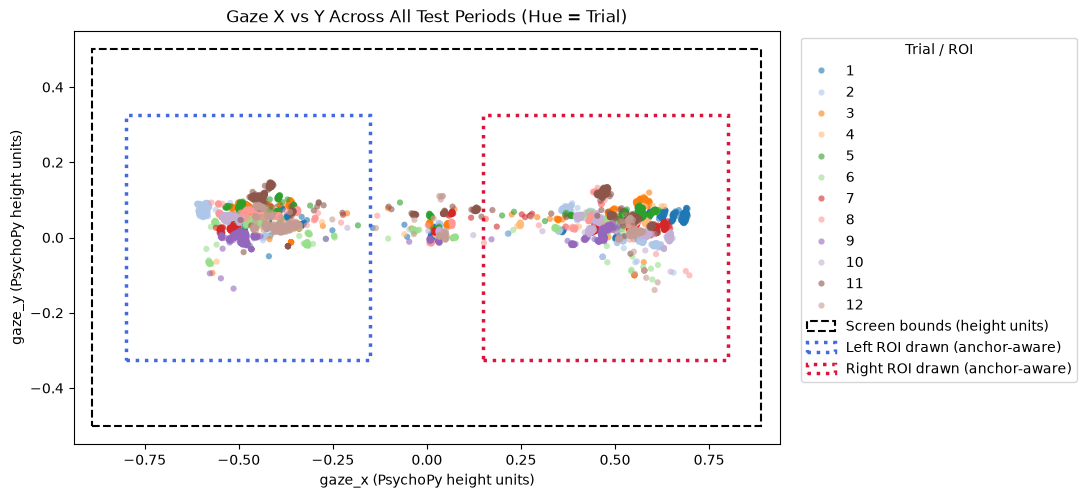

Points plotted: 7286
Trials represented: 12
Display: 1920x1080 (aspect=1.778)
Screen bounds (height units): x=[-0.889, 0.889], y=[-0.500, 0.500]

PsychoPy drawn ROI bounds (anchor-aware):
  Left  x=[-0.800, -0.150], y=[-0.325, 0.325]
  Right x=[0.150, 0.800], y=[-0.325, 0.325]


In [26]:
# Scatter of gaze positions (x, y) across all test periods, colored by trial
# Coordinates are interpreted in PsychoPy height units.

df_plot = df_test.copy()

df_plot['gaze_x'] = pd.to_numeric(df_plot['gaze_x'], errors='coerce')
df_plot['gaze_y'] = pd.to_numeric(df_plot['gaze_y'], errors='coerce')

# Assign test period index (1 or 2) within each trial and keep only test rows
df_plot['test_period_num'] = df_plot['Test_Period.started'].notna().groupby(df_plot['trial_number']).cumsum()
df_plot = df_plot[df_plot['test_period_num'].between(1, 2)]

df_plot = df_plot.dropna(subset=['gaze_x', 'gaze_y', 'trial_number'])
df_plot['trial_number'] = df_plot['trial_number'].astype(int).astype(str)

# PsychoPy height-units bounds using your display resolution (1920 x 1080)
screen_width_px = 1920
screen_height_px = 1080
screen_aspect = screen_width_px / screen_height_px

y_min, y_max = -0.5, 0.5
x_half = 0.5 * screen_aspect
x_min, x_max = -x_half, x_half

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(
    data=df_plot,
    x='gaze_x',
    y='gaze_y',
    hue='trial_number',
    palette='tab20',
    s=20,
    alpha=0.6,
    linewidth=0,
    ax=ax,
)

# Draw the visible screen area in height units
screen_rect = plt.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    fill=False,
    edgecolor='black',
    linestyle='--',
    linewidth=1.5,
    label='Screen bounds (height units)',
)
ax.add_patch(screen_rect)

# ROI settings from Builder
roi_w, roi_h = 0.65, 0.65
left_pos = (-0.8, 0.0)
right_pos = (0.8, 0.0)

# Anchor-aware bounds as PsychoPy draws them:
# center-left: pos is the midpoint of the LEFT edge
left_drawn_x0 = left_pos[0]
left_drawn_x1 = left_pos[0] + roi_w
left_drawn_y0 = left_pos[1] - roi_h / 2
left_drawn_y1 = left_pos[1] + roi_h / 2

# center-right: pos is the midpoint of the RIGHT edge
right_drawn_x0 = right_pos[0] - roi_w
right_drawn_x1 = right_pos[0]
right_drawn_y0 = right_pos[1] - roi_h / 2
right_drawn_y1 = right_pos[1] + roi_h / 2

# Draw only PsychoPy-drawn ROI boundaries (anchor-aware)
left_roi_drawn = plt.Rectangle(
    (left_drawn_x0, left_drawn_y0),
    roi_w,
    roi_h,
    fill=False,
    edgecolor='royalblue',
    linestyle=':',
    linewidth=2.5,
    label='Left ROI drawn (anchor-aware)',
)
right_roi_drawn = plt.Rectangle(
    (right_drawn_x0, right_drawn_y0),
    roi_w,
    roi_h,
    fill=False,
    edgecolor='crimson',
    linestyle=':',
    linewidth=2.5,
    label='Right ROI drawn (anchor-aware)',
)
ax.add_patch(left_roi_drawn)
ax.add_patch(right_roi_drawn)

ax.set_title('Gaze X vs Y Across All Test Periods (Hue = Trial)')
ax.set_xlabel('gaze_x (PsychoPy height units)')
ax.set_ylabel('gaze_y (PsychoPy height units)')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(x_min - 0.05, x_max + 0.05)
ax.set_ylim(y_min - 0.05, y_max + 0.05)
ax.legend(title='Trial / ROI', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f'Points plotted: {len(df_plot)}')
print(f'Trials represented: {df_plot["trial_number"].nunique()}')
print(f'Display: {screen_width_px}x{screen_height_px} (aspect={screen_aspect:.3f})')
print(f'Screen bounds (height units): x=[{x_min:.3f}, {x_max:.3f}], y=[{y_min:.3f}, {y_max:.3f}]')
print('')
print('PsychoPy drawn ROI bounds (anchor-aware):')
print(f'  Left  x=[{left_drawn_x0:.3f}, {left_drawn_x1:.3f}], y=[{left_drawn_y0:.3f}, {left_drawn_y1:.3f}]')
print(f'  Right x=[{right_drawn_x0:.3f}, {right_drawn_x1:.3f}], y=[{right_drawn_y0:.3f}, {right_drawn_y1:.3f}]')